# Importing Libraries

In [1]:
import datetime
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from Add_In_Queries import *
from Rebalancing import *
from RiskMetrics import *

import matplotlib.pyplot as plt

# Strategic Asset Allocation

In [2]:
def get_previous_business_date(date):
    # Subtract one day from the given date
    previous_date = date - datetime.timedelta(days=1)
    # If the previous date is Saturday (5) or Sunday (6), adjust accordingly
    if previous_date.weekday() == 5:  # Saturday
        previous_date -= datetime.timedelta(days=1)
    elif previous_date.weekday() == 6:  # Sunday
        previous_date -= datetime.timedelta(days=2)
    return previous_date

In [3]:
# SAA=pd.read_excel('SAA Allocations.xlsx',index_col=1)
# SAA=pd.read_excel('SAA Allocation 2.xlsx',index_col=1)
# years=list(set(SAA['Year']))
# names=SAA['Name'].to_dict()
# list_index=set(SAA.index)

# SAA

## SAA Matrix

In [4]:
years=[2024,2025]
idx_to_replace={'125231':'294368'}
index_map={}
SAA_dataframe=pd.DataFrame()
for year in years:
    temp_date='01/01/'+str(year)
    temp=retrieve_bench_composition('E143',temp_date)
    temp['Year']=year
    index_map[year]=temp
    
    SAA_dataframe=pd.concat([SAA_dataframe,temp],axis=0)
# pd.concat([retrieve_bench_composition('E143','01/01/2024'),retrieve_bench_composition('E143','01/01/2025')],axis=0)

SAA_dataframe.columns=['Index Code','Index Name','Weights','Year']
SAA_dataframe['Weights']=SAA_dataframe['Weights'].astype(float)
SAA_dataframe=SAA_dataframe.set_index('Index Code')
SAA_dataframe.rename(index=idx_to_replace,inplace=True)
SAA_dataframe

,Index Name,Weights,Year
Index Code,,,
291,MSCI NORTH AMERICA,0.1100,2024
260747,ETFS HEDGED WTI CRUDE OIL,0.0050,2024
171336,ICE BOFA EURO TREASURY BILL INDEX,0.0500,2024
294368,GOLD SPOT $/OZ,0.0150,2024
271562,BLOOMBERG US AGGREGATE HEDGED,0.0600,2024
176,MSCI JAPAN,0.0175,2024
118128,ICE BOFA EURO LARGE CAP CORPORATE INDEX,0.1650,2024
340,MSCI EUROPE (15),0.0625,2024
258934,JP MORGAN EMBI GLOBAL HEDGED TO EUR,0.0100,2024


In [5]:
years=list(set(SAA_dataframe['Year']))
names=SAA_dataframe['Index Name'].to_dict()
list_index=set(SAA_dataframe.index)

## Prices of Indices

In [6]:
start_date='01/12/2022'
start_date_datetime=datetime.datetime.strptime(start_date,'%d/%m/%Y')


end_date_datetime=get_previous_business_date(datetime.date.today()-datetime.timedelta(2))

end_date=datetime.datetime.strftime(end_date_datetime,format='%d/%m/%Y')

In [7]:
idx_returns = {}

for idx in list_index:
    try:

        idx_returns[idx] = get_index_valuation(idx, start_date, end_date)
        
    except Exception as e:
        
        print(idx)

In [8]:
prices_dict = {}
idx_col = [1, 2, 3]
nonzero={}

for idx in idx_returns:
    
    temp=idx_returns[idx].set_index(4)
    temp[[1,2,3]]=temp[[1,2,3]].astype(float)
    col_prices=temp[[1,2,3]]
    nonz=col_prices.columns[(col_prices!=0).all()]
    prices_dict[idx]=col_prices[np.max(nonz)]
            

In [9]:
prices = pd.DataFrame()

for col in prices_dict:
    prices[col] = prices_dict[col]

In [10]:
# prices.to_excel('Prices SAA.xlsx')

In [11]:
# prices=pd.read_excel('Prices SAA.xlsx',index_col=0)
# prices=prices.ffill()
# prices_to_use=prices.copy()

In [12]:
# prices_to_use.rename(columns=names,inplace=True)

In [13]:
prices.index=pd.to_datetime(prices.index,dayfirst=True)
prices=prices.ffill()
prices_to_use=prices.copy()

## SAA Returns

In [14]:
dates_to_use=get_rebalancing_dates(prices_to_use,frequency='Monthly')

In [15]:
matrix=pd.DataFrame(columns=list(list_index),index=dates_to_use,data=np.nan)

dico={}
for year in years:
    # temp=SAA.loc[SAA['Year']==year]['Weights'].to_dict()
    temp=SAA_dataframe.loc[SAA_dataframe['Year']==year]['Weights'].to_dict()
    dico[year]=temp
    


In [16]:
for year in years:
    temp_dico=dico[year]
    
    for col in matrix.columns:
        
        if col in temp_dico:
            matrix.loc[str(year):f"{year}-11", col] = temp_dico[col]
        else:
            matrix.loc[str(year):f"{year}-11", col] = 0

matrix=matrix.bfill()


In [17]:
saa=(rebalanced_dynamic_quantities(prices_to_use,matrix)*prices_to_use)
performance=pd.DataFrame()
performance['SAA']=saa.sum(axis=1)
# performance['Fixed Dynamic']=fixed_dynamic
# performance['Rebalanced']=rb


In [18]:
returns_fund=get_perf('E143',dateFrom=get_date_to_string(start_date_datetime),dateTo=get_date_to_string(end_date_datetime),type_code='DecalogCodePtf')

/home/jovyan/notebooks/alto_studio/Risk/Analysis/Portfolio Review/Multi Asset/SAA Recomputation/Add_In_Queries.py:44: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data["valuationDate"] = pd.to_datetime(


In [73]:
returns=performance.pct_change().copy()
returns['Fund']=returns_fund['grossperf']/100

In [84]:
((1+returns.loc['2023-12-31':].dropna()).cumprod()*100)

,SAA,Fund
2024-01-02,99.884083,99.854995
2024-01-03,99.674183,99.670727
2024-01-04,99.296062,99.239957
2024-01-05,99.192278,99.010595
2024-01-08,99.386997,99.060030
...,...,...
2025-08-04,110.047868,109.034864
2025-08-05,110.077720,109.099666
2025-08-06,110.048979,109.151173
2025-08-07,110.169731,109.214793


In [74]:
results=((1+returns.loc['2023-12-31':].dropna()).cumprod()*100)

<Axes: >

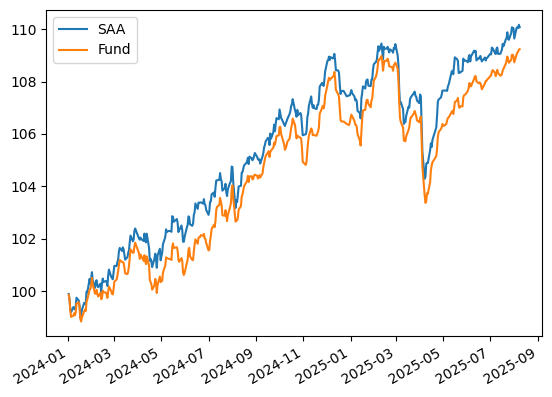

In [75]:
results.plot()

### Index Components

In [22]:
saa_ptf_weights=saa.iloc[-1]/saa.iloc[-1].sum()
current_saa_index=saa_ptf_weights.index
index=set(SAA_dataframe.index)
idx_components={}
for idx in index:
    
    try:
        idx_components[idx]=retrieve_index_composition(idx,end_date)
    
    
    except Exception as e:
        
        
        print(idx)

/home/jovyan/notebooks/alto_studio/Risk/Analysis/Portfolio Review/Multi Asset/SAA Recomputation/Add_In_Queries.py:115: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.DataFrame(data).replace('soapenc:string',0)


260747
294368


In [23]:
duration_per_idx={}
exposure_per_index=pd.DataFrame()
# instrument_per_index={}                                
for idx in current_saa_index:
    
    try:
        temp=idx_components[idx].set_index(4)
        list_of_instruments=list(set(temp.index))
        # instrument_per_index[idx]=get_instrument_data_ISIN(list_of_instruments,end_date).set_index('instCodeIsin')

        # duration_per_idx[idx]=[np.sum(temp[26].astype(float)*saa_ptf_weights[idx]*temp[2].astype(float)),np.sum(temp[26].astype(float)*temp[2].astype(float))]
        # temp['Exposure']=temp[2].astype(float)*saa_ptf_weights[idx]
        # temp['Duration Contribution']=temp[26].astype(float)*saa_ptf_weights[idx]*temp[2].astype(float)
        
        
        temp['Instrument Weights']=temp[2].astype(float)
        temp['Instrument Duration']=temp[26].astype(float)
        temp['Index held in']=idx
        exposure_per_index=pd.concat([exposure_per_index,temp],axis=0)
        
    except Exception as e:
        
        print(idx)


260747
294368


In [24]:
exposure_to_copy=exposure_per_index.copy()
exposure_to_copy=exposure_to_copy.loc[~exposure_to_copy.index.isin([0,'CASHUSD00000','CASHEUR00000']),['Instrument Weights','Instrument Duration','Index held in']]

### Index Instrment Data

In [25]:
unique_instruments=set(exposure_to_copy.index)
batch={}
window_size=1000

for i in range(0,len(unique_instruments),window_size):
    
    if i<len(unique_instruments)-window_size:
        temp=list(unique_instruments)[i:i+window_size]
        
    else:
        temp=list(unique_instruments)[i:len(unique_instruments)]
        
    batch[i]=get_instrument_data_ISIN(temp,end_date).set_index('instCodeIsin')
    print(i)

/home/jovyan/notebooks/alto_studio/Risk/Analysis/Portfolio Review/Multi Asset/SAA Recomputation/Add_In_Queries.py:306: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.DataFrame(data,columns=columns).replace('soapenc:string',0)


0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000


### Lookthrough View

In [26]:
instrument_table=pd.DataFrame()

for key in batch:
    
    instrument_table=pd.concat([instrument_table,batch[key]])
    
instrument_table=instrument_table.loc[~instrument_table.index.duplicated()]    

In [27]:
exposure_to_copy['Weights in SAA']=exposure_to_copy['Index held in'].map(saa_ptf_weights)
exposure_to_copy['Weighted Duration']=exposure_to_copy['Weights in SAA']*exposure_to_copy['Instrument Duration']*exposure_to_copy['Instrument Weights']
exposure_to_copy['Exposure']=exposure_to_copy['Weights in SAA']*exposure_to_copy['Instrument Weights']

In [28]:
aggregated_view=exposure_to_copy[['Weighted Duration','Exposure']].copy()
aggregated_view=aggregated_view.groupby(aggregated_view.index).sum()
aggregated_view=pd.concat([aggregated_view,instrument_table],axis=1)

In [29]:
# list(lookthrough_table.columns)

In [30]:
aggregated_view[['Exposure','Weighted Duration','instGroupName']].groupby('instGroupName').sum().sort_values(by='Exposure',ascending=False).round(4)

,Exposure,Weighted Duration
instGroupName,,
BOND,0.6883,3.5943
EQUITY,0.2207,0.0000
MONEY MARKET,0.0651,0.0253


In [31]:
# exposure_per_index['Duration Contribution'].sum()

# Efficient Frontier

In [32]:
current_saa=SAA_dataframe[SAA_dataframe['Year']==2025].copy()
current_saa

,Index Name,Weights,Year
Index Code,,,
118128,ICE BOFA EURO LARGE CAP CORPORATE INDEX,0.1775,2025
176,MSCI JAPAN,0.0175,2025
258934,JP MORGAN EMBI GLOBAL HEDGED TO EUR,0.0200,2025
340,MSCI EUROPE (15),0.0625,2025
116408,ICE BOFA EURO HIGH YIELD INDEX,0.0450,2025
124572,BLOOMBERG EURO AGGREGATE (E),0.3225,2025
291,MSCI NORTH AMERICA,0.1100,2025
108579,ICE BOFA US HIGH YIELD INDEX HEDGED,0.0050,2025
98,MSCI EM (EMERGING MARKETS),0.0200,2025


In [33]:
current_weights=current_saa['Weights'].to_numpy()
prices_for_analysis=prices[current_saa.index].copy()
returns_for_analysis=prices_for_analysis.pct_change()

In [34]:
prices_for_analysis

,118128,176,258934,340,116408,124572,291,108579,98,97,171336,260747,294368,271562
4,,,,,,,,,,,,,,
2022-12-01,266.786,246.790700,387.62445,316.511200,318.652,231.895762,568.076500,1327.569,689.263600,712.221600,142.224,2.6190,68.233,201.818256
2022-12-02,266.481,243.893700,388.65036,315.983600,318.739,231.375230,567.904000,1327.313,686.991000,704.380700,142.231,2.5730,67.920,202.465795
2022-12-05,266.744,240.518800,387.87740,314.747100,318.960,231.422980,554.525500,1324.691,690.773600,706.623000,142.235,2.5165,67.223,200.910908
2022-12-06,267.670,240.808100,386.38600,313.006600,318.803,232.396859,547.464000,1320.867,684.556400,703.780200,142.253,2.3745,67.110,201.613545
2022-12-07,267.922,240.156400,387.58414,311.000800,318.349,232.720184,546.558500,1320.209,674.539100,695.693000,142.263,2.3230,67.489,203.264833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-04,302.013,319.082857,455.02130,420.153312,400.882,246.581321,832.421100,1599.602,856.725463,817.223337,154.171,2.6465,115.682,210.344705
2025-08-05,302.178,320.798560,455.73280,420.723763,401.149,246.727343,829.021779,1600.137,862.963335,823.628824,154.180,2.5930,115.917,210.391898
2025-08-06,302.095,322.574796,455.48580,420.279305,401.255,246.521287,831.102218,1601.078,857.346619,826.663464,154.188,2.6060,115.048,210.275144


In [35]:
portfolio=RiskAnalysis(returns_for_analysis)

In [36]:
frontier_weights, frontier_returns, frontier_risks, frontier_sharpe_ratio=portfolio.efficient_frontier()

In [37]:
frontier = pd.DataFrame(
        {
            "Returns": frontier_returns,
            "Volatility": frontier_risks,
            "Sharpe Ratio": frontier_sharpe_ratio,
        }
    )

In [59]:
# optimal_weights=portfolio.optimize(objective='sharpe_ratio',constraints=[{'type': 'ineq', 'fun': lambda weights: 0.3-weights},
#                                                                         {'type': 'ineq', 'fun': lambda weights: weights-0.03}])

fund_returns,volatility_fund=portfolio.performance(current_weights),portfolio.variance(current_weights)
fund_sharpe_ratio=fund_returns/volatility_fund

optimal_weights=portfolio.optimize(objective='sharpe_ratio',constraints=[{'type': 'ineq', 'fun': lambda weights: portfolio.variance(weights)-volatility_fund},
                                                                        {'type': 'eq', 'fun': lambda weights: 0.015-weights[12]},
                                                                        {'type': 'eq', 'fun': lambda weights: 0.005-weights[11]},
                                                                        {'type': 'ineq', 'fun': lambda weights: 0.3-weights}])
                                   
optimal_fund_returns,optimal_fund_volatility=portfolio.performance(optimal_weights),portfolio.variance(optimal_weights)
optimal_fund_sharpe_ratio=optimal_fund_returns/optimal_fund_volatility

optimized_information_ratio=portfolio.optimize_information_ratio(current_weights)
vol_info=portfolio.variance(optimized_information_ratio)
ret_info=portfolio.performance(optimized_information_ratio)
sharpe_info=ret_info/vol_info

inventory=portfolio.inventory(optimal_weights)
inventory.columns=['Optimal Weights']

inventory_info=portfolio.inventory(optimized_information_ratio)
inventory_info.columns=['Information Weights']

In [60]:
weights_comparison=pd.concat([current_saa[['Index Name','Weights']],inventory,inventory_info],axis=1).round(4).fillna(0)
weights_comparison['Spread']=weights_comparison['Optimal Weights']-weights_comparison['Weights']
weights_comparison.sort_values(by='Spread',ascending=False)

,Index Name,Weights,Optimal Weights,Information Weights,Spread
108579,ICE BOFA US HIGH YIELD INDEX HEDGED,0.0050,0.3000,0.0017,0.2950
116408,ICE BOFA EURO HIGH YIELD INDEX,0.0450,0.3000,0.1181,0.2550
176,MSCI JAPAN,0.0175,0.0331,0.0175,0.0156
291,MSCI NORTH AMERICA,0.1100,0.1239,0.1126,0.0139
258934,JP MORGAN EMBI GLOBAL HEDGED TO EUR,0.0200,0.0287,0.0219,0.0087
294368,GOLD SPOT $/OZ,0.0150,0.0150,0.0223,0.0000
260747,ETFS HEDGED WTI CRUDE OIL,0.0050,0.0050,0.0038,0.0000
340,MSCI EUROPE (15),0.0625,0.0546,0.0607,-0.0079
97,MSCI PACIFIC FREE EX JAPAN,0.0100,0.0000,0.0040,-0.0100
98,MSCI EM (EMERGING MARKETS),0.0200,0.0000,0.0187,-0.0200


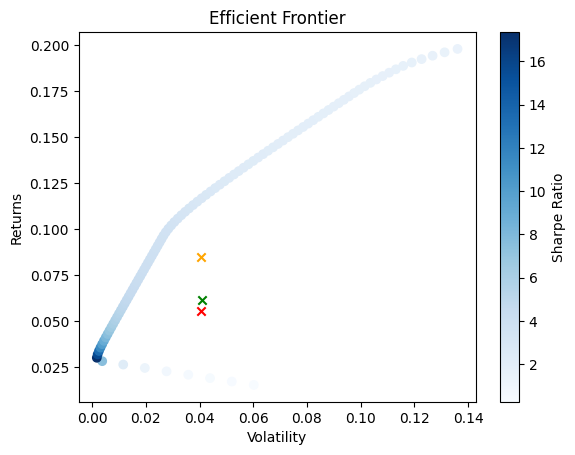

In [61]:

volatility = frontier['Volatility']
returns = frontier['Returns']
sharpe_ratio = frontier['Sharpe Ratio']

# Create scatter plot
scatter = plt.scatter(
    volatility,
    returns,
    c=sharpe_ratio,
    cmap='Blues',
)

scatter_fund=plt.scatter(
    volatility_fund,
    fund_returns,
    c='red',
    marker='x'
)

scatter_fund_optimal=plt.scatter(
    optimal_fund_volatility,
    optimal_fund_returns,
    c='orange',
    marker='x'
)


scatter_fund_optimal=plt.scatter(
    vol_info,
    ret_info,
    c='green',
    marker='x'
)


# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio')

# Add labels and title
plt.xlabel('Volatility')
plt.ylabel('Returns')
plt.title('Efficient Frontier')

plt.show()

<Axes: >

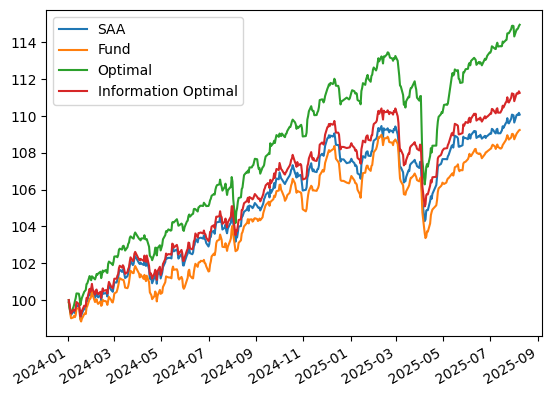

In [85]:
time_series=results.copy()

time_series['Optimal']=rebalanced_portfolio(prices_for_analysis.loc[results.index],optimal_weights,frequency='Monthly').sum(axis=1)
time_series['Information Optimal']=rebalanced_portfolio(prices_for_analysis.loc[results.index],optimized_information_ratio,frequency='Monthly').sum(axis=1)
time_series.plot()

In [63]:
exposure_to_copy['Weights in SAA']=exposure_to_copy['Index held in'].map(saa_ptf_weights)
exposure_to_copy['Weighted Duration']=exposure_to_copy['Weights in SAA']*exposure_to_copy['Instrument Duration']*exposure_to_copy['Instrument Weights']
exposure_to_copy['Exposure']=exposure_to_copy['Weights in SAA']*exposure_to_copy['Instrument Weights']

exposure_to_copy['Optimal Weights']=exposure_to_copy['Index held in'].map(inventory['Optimal Weights'])
exposure_to_copy['Optimal Duration']=exposure_to_copy['Optimal Weights']*exposure_to_copy['Instrument Duration']*exposure_to_copy['Instrument Weights']
exposure_to_copy['Optimal Exposure']=exposure_to_copy['Optimal Weights']*exposure_to_copy['Instrument Weights']

exposure_to_copy['Information Weights']=exposure_to_copy['Index held in'].map(inventory_info['Information Weights'])
exposure_to_copy['Information Duration']=exposure_to_copy['Information Weights']*exposure_to_copy['Instrument Duration']*exposure_to_copy['Instrument Weights']
exposure_to_copy['Information Exposure']=exposure_to_copy['Information Weights']*exposure_to_copy['Instrument Weights']


aggregated_view=exposure_to_copy[['Exposure','Information Exposure','Optimal Exposure','Weighted Duration','Information Duration','Optimal Duration']].copy()
aggregated_view=aggregated_view.groupby(aggregated_view.index).sum()
aggregated_view=pd.concat([aggregated_view,instrument_table],axis=1)

In [69]:
axis='issuerRatingAmundi'
view=aggregated_view[['Exposure','Information Exposure','Optimal Exposure','Weighted Duration','Information Duration','Optimal Duration',axis]].groupby(axis).sum().sort_values(by='Optimal Exposure',ascending=False)
view.round(4)

,Exposure,Information Exposure,Optimal Exposure,Weighted Duration,Information Duration,Optimal Duration
issuerRatingAmundi,,,,,,
BB+,0.0142,0.0280,0.0962,0.0311,0.0706,0.2785
BB-,0.0098,0.0191,0.0944,0.0171,0.0395,0.2360
BB,0.0108,0.0215,0.0934,0.0219,0.0506,0.2648
NR,0.0337,0.0351,0.0778,0.0687,0.0726,0.1490
BBB,0.1200,0.1117,0.0753,0.4535,0.4569,0.1731
B,0.0056,0.0133,0.0616,0.0133,0.0324,0.1476
B+,0.0051,0.0112,0.0595,0.0107,0.0248,0.1478
BBB+,0.0855,0.0899,0.0588,0.2812,0.3015,0.1397
A-,0.1244,0.1132,0.0567,0.4715,0.4618,0.1013
